In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import astropy.units as u
import astropy.constants as c

import sys
sys.path.append('/global/homes/c/cpopik/CAPPIBARAS')

import Plots
importlib.reload(Plots)

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
    'figure.figsize': [9, 6], 'axes.titlesize':30, 'legend.fontsize': 15, 'legend.title_fontsize': 20,
    'axes.labelsize':25, 'xtick.labelsize':15, 'ytick.labelsize':15
})

# Cosmological Parameters

In [4]:
import HaloModels
importlib.reload(HaloModels)

ast = HaloModels.astropy_model()
pyc = HaloModels.pyccl_model()
col = HaloModels.colossus_model()

print(ast.Parameters), print(pyc.Parameters), print(col.Parameters)

['H0', 'Om0', 'Tcmb0', 'Neff', 'm_nu', 'Ob0']
['Omega_c', 'Omega_b', 'h', 'n_s', 'sigma8', 'A_s', 'Omega_k', 'Omega_g', 'Neff', 'm_nu', 'mass_split', 'w0', 'wa', 'T_CMB', 'T_ncdm', 'extra_parameters', 'transfer_function', 'matter_power_spectrum', 'baryonic_effects', 'mg_parametrization']
['Om0', 'flat', 'Ob0', 'ns', 'relspecies', 'H0', 'sigma8']


(None, None, None)

In [3]:
cosmopars = {
    'Om0':0.3,
    'Ob0':0.048,
    'H0':70.0,
    'sigma8':0.8,
    'ns':0.965,
    'T_CMB':2.7255
}

ast = HaloModels.astropy_model(cosmopars)
pyc = HaloModels.pyccl_model(cosmopars)
col = HaloModels.colossus_model(cosmopars)

print(ast.params), print(pyc.params), print(col.params)

{'name': 'Planck18 (modified)', 'meta': {'Oc0': 0.2607, 'n': 0.9665, 'sigma8': 0.8102, 'tau': 0.0561, 'z_reion': <Quantity 7.82 redshift>, 't0': <Quantity 13.787 Gyr>, 'reference': 'Planck Collaboration 2018, 2020, A&A, 641, A6  (Paper VI), Table 2 (TT, TE, EE + lowE + lensing + BAO)'}, 'H0': <Quantity 70. km / (Mpc s)>, 'Om0': 0.3, 'Tcmb0': <Quantity 2.7255 K>, 'Neff': 3.046, 'm_nu': <Quantity [0.  , 0.  , 0.06] eV>, 'Ob0': 0.048, 'Ode0': 0.6986045005303088, 'Odm0': 0.252, 'h': 0.7, 'hubble_distance': <Quantity 4282.7494 Mpc>, 'hubble_time': <Quantity 13.96846031 Gyr>, 'critical_density0': <Quantity 9.20387392e-30 g / cm3>, 'Ogamma0': 5.0468884259471206e-05, 'Tnu0': <Quantity 1.94536884 K>, 'nneutrinos': 3, 'neff_per_nu': 1.0153333333333332, 'massivenu': True, 'massivenu_mass': array([0.06]), 'nmassivenu': 1, 'nmasslessnu': 2, 'nu_y': array([357.91212097]), 'nu_y_list': [357.9121209673803], 'Onu0': 0.0013450305854317394, 'Ok0': 0.0, 'inv_efunc_scalar': <cyfunction flcdm_inv_efunc at 0

(None, None, None)

# Redshift Functions

In [37]:
import HaloModels
importlib.reload(HaloModels)

cosmopars = {'Om0':0.3,'Ob0':0.048,'H0':70.0,'sigma8':0.8,'ns':0.965,'T_CMB':2.7255}

ast = HaloModels.astropy_model(cosmopars)
pyc = HaloModels.pyccl_model(cosmopars)
col = HaloModels.colossus_model(cosmopars)


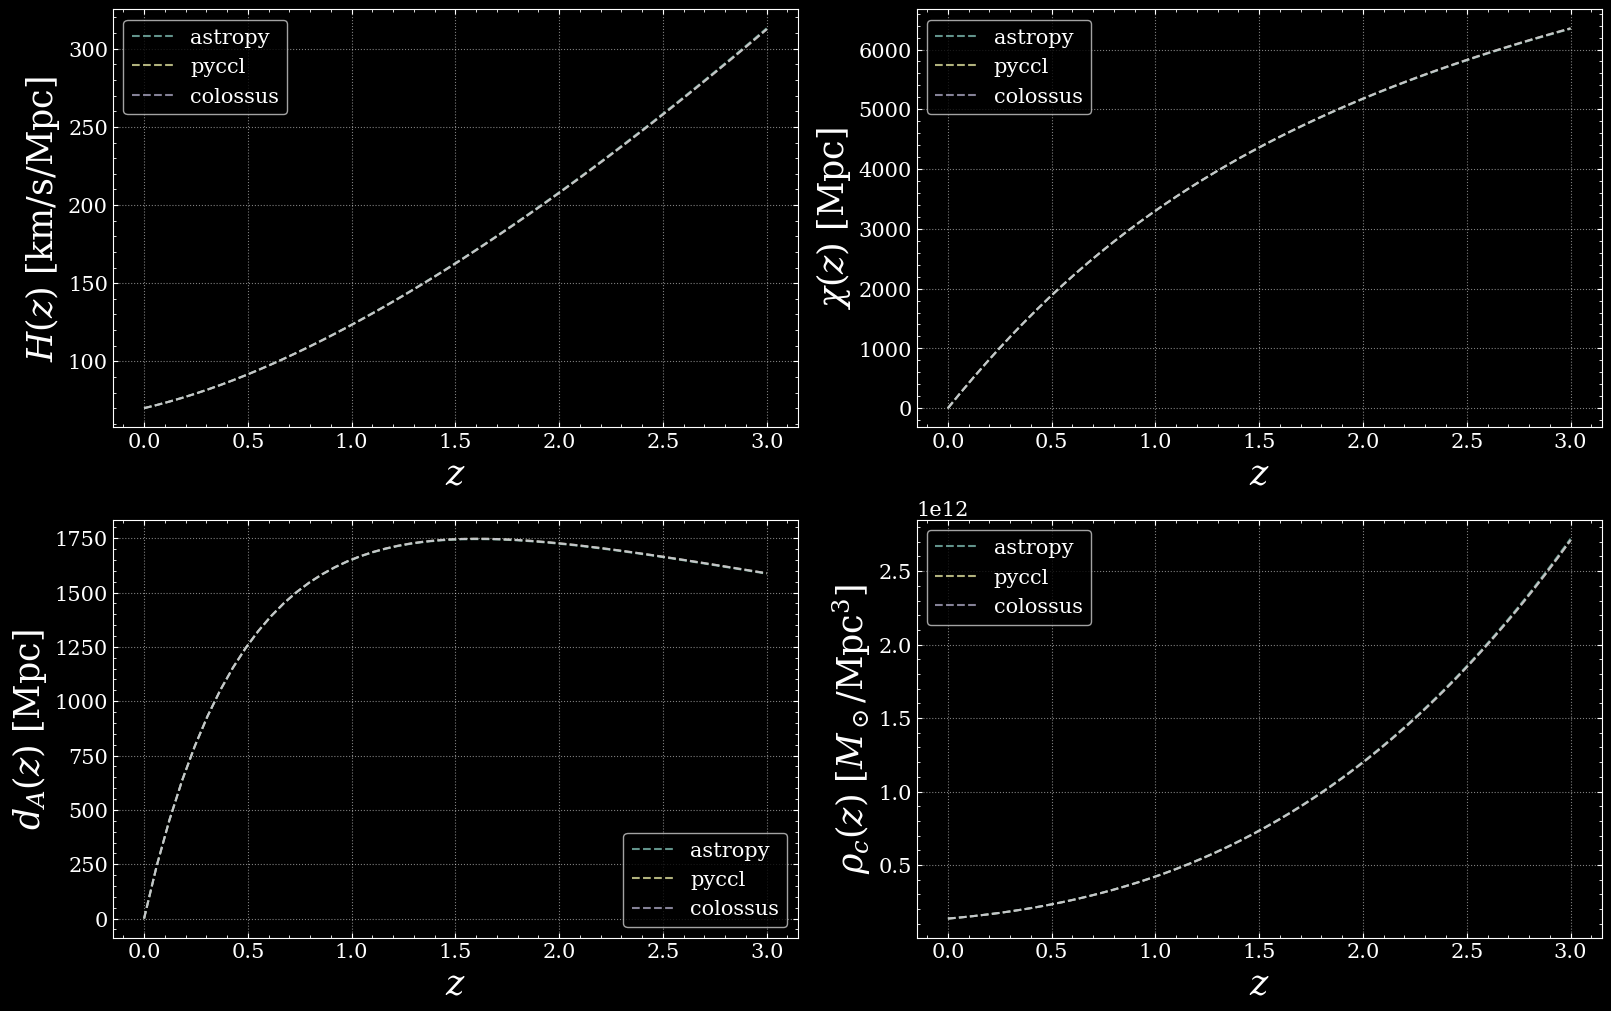

In [38]:
zs = np.linspace(0, 3)

fig, axs = plt.subplots(2, 2, figsize=(16, 10), layout='constrained')
axs=axs.flatten()

for mod, name in zip([ast, pyc, col], ['astropy', 'pyccl', 'colossus']):
    axs[0].plot(zs, mod.H(zs), alpha=0.7, ls='--', label=name)
    axs[1].plot(zs, mod.chi(zs), alpha=0.7, ls='--',label=name)
    axs[2].plot(zs, mod.dA(zs), alpha=0.7, ls='--',label=name)
    axs[3].plot(zs, mod.rhoc(zs), alpha=0.7, ls='--',label=name)

axs[0].set(ylabel=r'$H(z) \ [\text{km/s/Mpc}]$', xlabel=r'$z$'); axs[0].legend()
axs[1].set(ylabel=r'$\chi(z) \ [\text{Mpc}]$', xlabel=r'$z$'); axs[1].legend()
axs[2].set(ylabel=r'$d_A(z) \ [\text{Mpc}]$', xlabel=r'$z$'); axs[2].legend()
axs[3].set(ylabel=r'$\rho_c(z) \ [M_\odot/\text{Mpc}^3]$', xlabel=r'$z$'); axs[3].legend()

plt.show()

# Power Spectrum

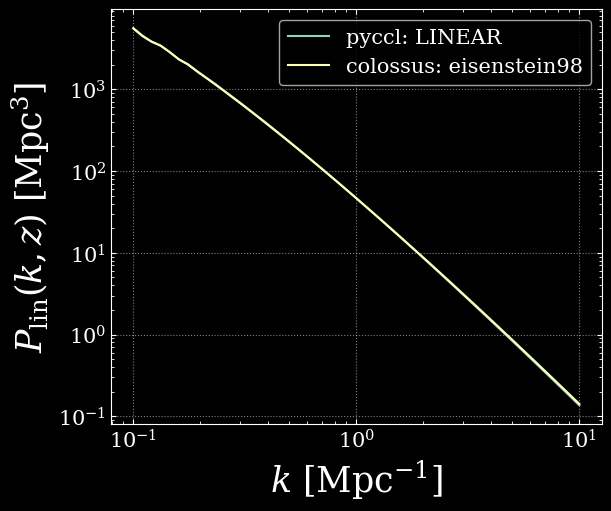

In [39]:
import HaloModels
importlib.reload(HaloModels)

cosmopars = {'Om0':0.3,'Ob0':0.048,'H0':70.0,'sigma8':0.8,'ns':0.965,'T_CMB':2.7255}
pyc = HaloModels.pyccl_model(cosmopars, PowSpec='LINEAR')
col = HaloModels.colossus_model(cosmopars, Cosmology='planck18', PlinMod='eisenstein98')


z, ks = 0.55, np.logspace(-1, 1, 50)

fig, ax = plt.subplots(1, 1, figsize=(6, 5), layout='constrained')

ax.loglog(ks, pyc.Plin(ks, z), label=f'pyccl: {pyc.PowSpec}')
ax.loglog(ks, col.Plin(ks, z), label=f'colossus: {col.PlinMod}')

ax.set(ylabel=r'$P_\text{lin}(k, z) \ [\text{Mpc}^3]$', xlabel=r'$k \ [\text{Mpc}^{-1}]$'); ax.legend()
plt.show()

# Mass Functions

In [47]:
import HaloModels
importlib.reload(HaloModels)

cosmopars = {'Om0':0.3,'Ob0':0.048,'H0':70.0,'sigma8':0.8,'ns':0.965,'T_CMB':2.7255}

MassDef = '200c'
MassFunc = 'Tinker08'
HaloBias = 'Tinker10'
Concentration = 'Bhattacharya13'

pyc = HaloModels.pyccl_model(cosmopars, MassDef=MassDef, MassFunc=MassFunc, HaloBias=HaloBias, Concentration=Concentration)
col = HaloModels.colossus_model(cosmopars, MassDef=MassDef, MassFunc=MassFunc, HaloBias=HaloBias, Concentration=Concentration)

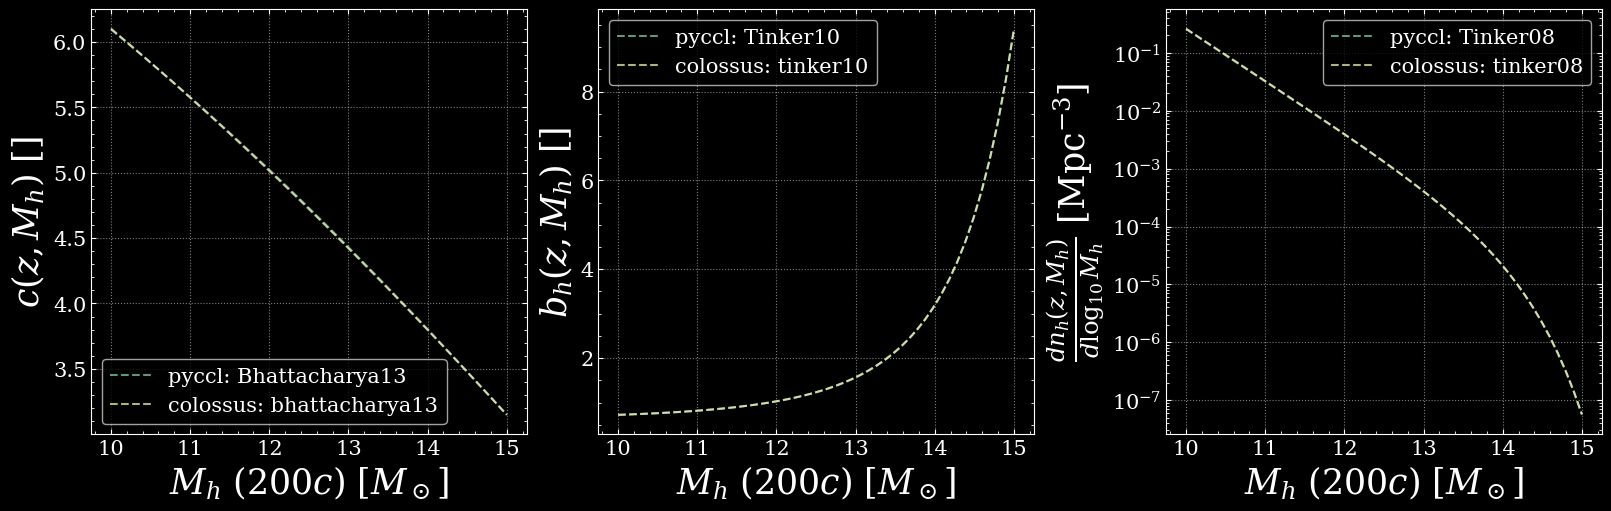

In [49]:
z, logMs = 0.55, np.linspace(10, 15)

fig, axs = plt.subplots(1, 3, figsize=(16, 5), layout='constrained')
axs = axs.flatten()

for mod, name in zip([pyc, col], ['pyccl', 'colossus']):
    axs[0].plot(logMs, mod.c(z, logMs), alpha=0.7, ls='--',label=f'{name}: {mod.Concentration}')
    axs[1].plot(logMs, mod.bh(z, logMs), alpha=0.7, ls='--',label=f'{name}: {mod.HaloBias}')
    axs[2].plot(logMs, mod.dndlogm(z, logMs), alpha=0.7, ls='--',label=f'{name}: {mod.MassFunc}')

axs[0].set(ylabel=r'$c(z, M_h) \ []$', xlabel=rf'$M_h \ ({MassDef}) \ [M_\odot]$'); axs[0].legend()
axs[1].set(ylabel=r'$b_h(z, M_h) \ []$', xlabel=rf'$M_h \ ({MassDef}) \ [M_\odot]$'); axs[1].legend()
axs[2].set(ylabel=r'$\frac{dn_h(z, M_h)}{d\log_{10} M_h}$ [Mpc$^{-3}$]', xlabel=rf'$M_h \ ({MassDef}) \ [M_\odot]$', yscale='log'); axs[2].legend()

plt.show()

# Mass/Radius Definitions

In [ ]:
import HaloModels
importlib.reload(HaloModels)

cosmopars = {'Om0':0.3,'Ob0':0.048,'H0':70.0,'sigma8':0.8,'ns':0.965,'T_CMB':2.7255}

MassDef = '200c'
Concentration = 'Bhattacharya13'

pyc = HaloModels.pyccl_model(cosmopars, MassDef=MassDef, Concentration=Concentration)
col = HaloModels.colossus_model(cosmopars, MassDef=MassDef,Concentration=Concentration)

In [ ]:
z, logMs = 0.55, np.linspace(10, 15)

fig, axs = plt.subplots(1, 3, figsize=(16, 5), layout='constrained')
axs = axs.flatten()

for mod, name in zip([pyc, col], ['pyccl', 'colossus']):
    axs[0].plot(logMs, mod.c(z, logMs), alpha=0.7, ls='--',label=f'{name}: {mod.Concentration}')
    axs[1].plot(logMs, mod.bh(z, logMs), alpha=0.7, ls='--',label=f'{name}: {mod.HaloBias}')
    axs[2].plot(logMs, mod.dndlogm(z, logMs), alpha=0.7, ls='--',label=f'{name}: {mod.MassFunc}')

axs[0].set(ylabel=r'$c(z, M_h) \ []$', xlabel=rf'$M_h \ ({MassDef}) \ [M_\odot]$'); axs[0].legend()
axs[1].set(ylabel=r'$b_h(z, M_h) \ []$', xlabel=rf'$M_h \ ({MassDef}) \ [M_\odot]$'); axs[1].legend()
axs[2].set(ylabel=r'$\frac{dn_h(z, M_h)}{d\log_{10} M_h}$ [Mpc$^{-3}$]', xlabel=rf'$M_h \ ({MassDef}) \ [M_\odot]$', yscale='log'); axs[2].legend()

plt.show()

In [ ]:
    # axs[0].plot(logMs, mod.rdel('200c')(z, logMs), alpha=0.7, ls='--', label=f'{name}: r200c')
    
    # axs[0].set(ylabel=r'$R_{200c}(z, M_h) \ [\text{Mpc}]$', xlabel=r'$M_h \ [M_\odot]$'); axs[0].legend()

In [ ]:
z, logMs = 0.55, np.geomspace(10, 15)

fig, axs = plt.subplots(2, 2, figsize=(16, 10), layout='constrained')
axs = axs.flatten()

axs[0].plot(logMs, pyc.logM_conv(z, logMs, '500c'), label=f'pyccl')

axs[0].plot(logMs, col.logM_conv(z, logMs, '500c'), label=f'colossus')

axs[0].set(ylabel=r'$M_{500c}(z, M_{200c})$', xlabel=r'$M_{200c} \ [M_\odot]$'); axs[0].legend()
axs[1].set(ylabel=r'$c(z, M_h) \ []$', xlabel=r'$M_h \ [M_\odot]$'); axs[1].legend()
axs[2].set(ylabel=r'$\frac{dn_h(z, M_h)}{d\log_{10} M_h}$ [Mpc$^{-3}$]', xlabel=r'$M_h \ [M_\odot]$', yscale='log'); axs[2].legend()
axs[3].set(ylabel=r'$b_h(z, M_h) \ []$', xlabel=r'$M_h \ [M_\odot]$'); axs[3].legend()

plt.show()

# In development

In [ ]:
import Studies
Studies.Amodeo2021().info

pyc = HaloModels.pyccl_model(Studies.Amodeo2021().info)
col = HaloModels.colossus_model(Studies.Amodeo2021().info)

In [ ]:
cosmopars = {'Om0':0.3,'Ob0':0.048,'H0':70.0,'T_CMB':2.7255}

import hmf
hmf.halos.mass_definitions.MassDefinition.get_models()

thing = MassFunction(z=z,Mmin=logMs0.min(), Mmax=logMs0.max(), dlog10m=logMs0[1]-logMs0[0], hmf_model="Tinker08", mdef_model="SOCritical", cosmo_model=ast.cosmology).dndlog10m



z, logMs = 0.55, np.linspace(10, 15)

fig, axs = plt.subplots(2, 2, figsize=(16, 10), layout='constrained')
axs = axs.flatten()

for mod, name in zip([pyc, col], ['pyccl', 'colossus']):
    axs[0].plot(logMs, mod.rdel('200c')(z, logMs), alpha=0.7, ls='--', label=f'{name}: r200c')
    axs[1].plot(logMs, mod.c(z, logMs), alpha=0.7, ls='--',label=f'{name}: {mod.Concentration}')
    axs[2].plot(logMs, mod.bh(z, logMs), alpha=0.7, ls='--',label=f'{name}: {mod.HaloBias}')
    axs[3].plot(logMs, mod.dndlogm(z, logMs), alpha=0.7, ls='--',label=f'{name}: {mod.MassFunc}')

logMs0 = np.log10(10**logMs*0.7)
thing = MassFunction(z=z,Mmin=logMs0.min(), Mmax=logMs0.max(), dlog10m=logMs0[1]-logMs0[0], hmf_model="Tinker08", mdef_model="SOCritical", cosmo_model=ast.cosmology).dndlog10m
axs[3].plot(logMs, thing*0.7**3, alpha=0.7, ls='--', label='hmf')

axs[0].set(ylabel=r'$R_{200c}(z, M_h) \ [\text{Mpc}]$', xlabel=r'$M_h \ [M_\odot]$'); axs[0].legend()
axs[1].set(ylabel=r'$c(z, M_h) \ []$', xlabel=r'$M_h \ [M_\odot]$'); axs[1].legend()
axs[2].set(ylabel=r'$b_h(z, M_h) \ []$', xlabel=r'$M_h \ [M_\odot]$'); axs[2].legend()
axs[3].set(ylabel=r'$\frac{dn_h(z, M_h)}{d\log_{10} M_h}$ [Mpc$^{-3}$]', xlabel=r'$M_h \ [M_\odot]$', yscale='log'); axs[3].legend()

plt.show()

In [183]:
import hmf


In [ ]:
hmf.Cosmology.get

<function hmf.cosmology.cosmo.get_cosmo(name)>

In [192]:
hmf.mass_definitions.MassDefinition.get_models()

{'SphericalOverdensity': hmf.halos.mass_definitions.SphericalOverdensity,
 'SOGeneric': hmf.halos.mass_definitions.SOGeneric,
 'SOMean': hmf.halos.mass_definitions.SOMean,
 'SOCritical': hmf.halos.mass_definitions.SOCritical,
 'SOVirial': hmf.halos.mass_definitions.SOVirial,
 'FOF': hmf.halos.mass_definitions.FOF}

In [ ]:
from hmf import MassFunction
logMs = np.linspace(10, 15)
zs = np.linspace(0, 2, 5)
hmf_mod = lambda z, logMs: np.vectorize(hmf.MassFunction)(z=z,Mmin=logMs.min(), Mmax=logMs.max(), dlog10m=logMs[1]-logMs[0], hmf_model="SMT").dndlog10m
hmf_mod(zs, logMs)

SyntaxError: '(' was never closed (1574552146.py, line 4)

In [ ]:
import HaloModels
importlib.reload(HaloModels)

cosmopars = {'Om0':0.25,'Ob0':0.045,'H0':70.0,'sigma8':0.8344,'ns':0.9624}
pyc = HaloModels.pyccl_model(cosmopars, PowSpec='LINEAR')
col = HaloModels.colossus_model(cosmopars, Cosmology='planck18', PlinMod='eisenstein98')


z, ks = 0.55, np.logspace(-1, 1, 50)

fig, ax = plt.subplots(1, 1, figsize=(6, 5), layout='constrained')

ax.loglog(ks, pyc.Plin(ks, z), label=f'pyccl: {pyc.PowSpec}')
ax.loglog(ks, col.Plin(ks, z), label=f'colossus: {col.PlinMod}')
ax.loglog(ks, mopc.Plin(ks, z), label='mopc')

from hmf import transfer
h = transfer.Transfer().cosmo.h
ax.loglog(ks, mopc.Plin(ks/h, z)/h**3, label='mopc edit')

ax.set(ylabel=r'$P_\text{lin}(k, z) \ [\text{Mpc}^3]$', xlabel=r'$k \ [\text{Mpc}^{-1}]$'); ax.legend()
plt.show()